# Critical line: SAFT-P 2x2 vs 3x3 vs Monte Carlo

Direct answer to R2C1.  The published SAFT-P class definition is used throughout
(`internal_term="mean_energy"`: the Boltzmann-averaged internal energy in the class exponent
with multiplicity 1), so 2x2 and 3x3 differ **only** by the cluster size.  The Monte Carlo
critical line is the finite-size-scaling continuation logged in
`results_logs/all_trace_coexist_{stick,l}.out`.

### Coordinates

The MC traces log `theta* : (eps_nd, eps_sp, mu, Lambda, s, r)` at every converged
continuation step.  These are the same two couplings the SAFT-P notebooks call
$(\varepsilon_c, \varepsilon_a)$:

$$\varepsilon_{\rm nd} \equiv \varepsilon_c \quad\text{(non-directional, any particle pair)},
\qquad
\varepsilon_{\rm sp} \equiv \varepsilon_a \quad\text{(extra sticky-patch attraction)},$$

matching `J[:-1,:-1] -= eps_c; J[1,1] = -eps_a` in the builders.  This is the identification
`stick_l_critical_lines.ipynb` already uses when it overlays the two — no rescaling.

### The MC reference is the paper's own curve

`paper_curves.py` is a verbatim port of the smoothing chain in
`stick_l_critical_lines.ipynb`: the theta* records are filtered (x >= 0, and x >= 0.56 for the
L), pushed through `gaussian_smooth_xy_no_edge_curvature(sigma=50, n=800/900)` with the
linear-slope edge padding, and floor-trimmed for the L.  Everything below is measured against
*that* curve, not against a raw interpolation of the trace, so the comparison is on the same
footing as the published figure.

The smoothing turns out to matter very little: the smoothed and raw MC lines agree to
$|\Delta\varepsilon_a| \le 0.15$ everywhere except the two end points, where the linear
padding pulls the curve down by $\approx 0.25$.  The cell in section 2 shows this explicitly.

The published SAFT-P curve is reconstructed the same way (per-$\varepsilon_c$ minima of
`spinodal_{stick,l}_shaped_reduced_scan.npz`, `UnivariateSpline(k=3, s=0.5 n)`, then the same
Gaussian pass) and carried as a row in the table, so the new lines can be read against what is
actually printed in the paper.

### What "critical line" means here

For each $\varepsilon_c$, the **lower edge** in $\varepsilon_a$: the smallest $\varepsilon_a$
at which the convex-envelope construction finds a common tangent with barrier $>10^{-4}$.
That is the quantity the published scans read off (`min eps_a` at each $\varepsilon_c$), and
for the L-shape the extra `len(spinodal) > 1` condition from `spinodal_l_shaped.ipynb` is
applied as well.

`critical_eps_a_lower_edge` finds it by a coarse scan followed by bisection inside the
bracket, rather than by bisecting from $\varepsilon_a=0$ — the L two-phase region is a band
in $\varepsilon_a$, so a plain bisection would be invalid there.

### The 3x3 interior site

A 3x3 plaquette has one site the boundary signature cannot see.  Two ways to handle it, both
reported below:

* `interior_key="none"` — Boltzmann-average it (the literal generalisation of the published
  recipe).  Its occupancy is then frozen at the ideal value, so $\phi$ cannot go below
  $2/27$ (stick) or $4/45$ (L) and there is no pure-solvent phase.
* `interior_key="occupancy"` — label the class by the interior occupancy as well.  Exact
  composition, $\phi\in[0,1]$, exactly twice as many classes.

The 2x2 column is unaffected by this choice (no interior sites), so it is a clean reference.

In [1]:
%matplotlib inline
import sys, os, json, time
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))

import numpy as np
import matplotlib.pyplot as plt

from saftp_scan_nxn import GEOMETRIES, critical_eps_a_lower_edge
from mc_critical_lines import mc_line, mc_eps_a_at_eps_c
from paper_curves import (paper_mc_curve, paper_saftp_curve, apply_paper_smoothing,
                          eval_curve, lower_edge_from_npz)

DATA = os.path.abspath(os.path.join(os.getcwd(), '..', 'data'))
LOGS = os.path.abspath(os.path.join(os.getcwd(), '..', 'results_logs'))
PHIS = np.linspace(0.01, 0.99, 151)
TRACE = {'stick': os.path.join(LOGS, 'all_trace_coexist_stick.out'),
         'L':     os.path.join(LOGS, 'all_trace_coexist_l.out')}

for g, p in TRACE.items():
    d = mc_line(p)
    print(f"{g:6s} MC trace: {len(d['raw_eps_a'])} converged theta* records, "
          f"{len(d['eps_a'])} distinct eps_a, "
          f"eps_a in [{d['eps_a'].min():.2f}, {d['eps_a'].max():.2f}], "
          f"eps_c in [{d['eps_c'].min():.3f}, {d['eps_c'].max():.3f}]")

stick  MC trace: 323 converged theta* records, 277 distinct eps_a, eps_a in [0.00, 5.84], eps_c in [0.391, 1.767]
L      MC trace: 178 converged theta* records, 178 distinct eps_a, eps_a in [0.00, 5.82], eps_c in [0.905, 1.767]


## 1. Compute (or load) the SAFT-P critical lines

`RUN = False` loads the stored result.  Recomputing takes roughly 1.5 h: the L 3x3 curves are
~25 s each (25,440 classes) and each $\varepsilon_c$ needs ~15 curves to bracket and refine
the edge.

In [2]:
RUN = False
RESULT_JSON = os.path.join(DATA, 'critical_line_2x2_3x3_meanE.json')

EC_STICK = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2]
EC_L     = [1.10, 1.20, 1.30, 1.40, 1.50, 1.60, 1.70]
SCAN     = np.array([0., .5, 1., 1.5, 2., 2.5, 3., 4., 5., 6., 7., 8., 9., 10.])

# (geometry, eps_c list, n, interior_key, require_two_spinodal)
JOBS = [
    ('stick', EC_STICK, 2, 'none',      False),
    ('L',     EC_L,     2, 'none',      True),
    ('stick', EC_STICK, 3, 'occupancy', False),
    ('stick', EC_STICK, 3, 'none',      False),
    ('L',     EC_L,     3, 'occupancy', True),
    ('L',     EC_L,     3, 'none',      True),
]

if RUN:
    results = []
    for (geom, ecs, n, ik, req) in JOBS:
        print(f"=== {geom} n={n} interior={ik}", flush=True)
        for ec in ecs:
            t = time.time()
            ea, info = critical_eps_a_lower_edge(
                geom, ec, n=n, eps_a_scan=SCAN, refine=6, phis=PHIS,
                interior_key=ik, internal_term='mean_energy',
                barrier_tol=1e-4, require_two_spinodal=req)
            results.append(dict(geometry=geom, eps_c=ec, n=n, interior_key=ik,
                                internal_term='mean_energy', require_two_spinodal=req,
                                eps_a_crit=float(ea), status=info['status'],
                                wall=round(time.time() - t, 1)))
            print(results[-1], flush=True)
            json.dump(results, open(RESULT_JSON, 'w'), indent=1)
else:
    results = json.load(open(RESULT_JSON))

def line(geom, n, ik):
    d = {r['eps_c']: r['eps_a_crit'] for r in results
         if r['geometry'] == geom and r['n'] == n and r['interior_key'] == ik}
    ecs = np.array(sorted(d))
    return ecs, np.array([d[e] for e in ecs])

print(len(results), 'records')

57 records


## 2. The comparison

$\varepsilon_a$ at the critical line, at fixed $\varepsilon_c$.  The last two columns are the
signed deviation from MC; the summary line is over the range where the MC trace actually has
support and the SAFT-P line has not yet saturated at $\varepsilon_a = 0$.

In [3]:
# how much does the paper's smoothing move the MC reference?
print("MC reference: paper-smoothed curve vs raw interpolation of the trace\n")
for geom, ecs in [('stick', [0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 1.6]),
                  ('L',     [1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7])]:
    xm, ym = paper_mc_curve(geom, LOGS)
    sm = eval_curve(xm, ym, ecs)
    raw = mc_eps_a_at_eps_c(TRACE[geom], ecs)
    print(f"  {geom:6s} " + "  ".join(f"{c:.2f}:{s_-r:+.3f}" for c, s_, r in zip(ecs, sm, raw)))

MC reference: paper-smoothed curve vs raw interpolation of the trace

  stick  0.50:-0.273  0.70:+0.041  0.90:+0.037  1.10:+0.007  1.30:-0.033  1.50:-0.001  1.60:+0.002
  L      1.10:-0.246  1.20:-0.024  1.30:-0.007  1.40:+0.013  1.50:+0.018  1.60:+0.036  1.70:-0.038


In [4]:
def table(geom, fit_range):
    ec2, a2  = line(geom, 2, 'none')
    _,   a3o = line(geom, 3, 'occupancy')
    _,   a3n = line(geom, 3, 'none')

    xm, ym = paper_mc_curve(geom, LOGS)          # paper's MC curve
    xs, ys = paper_saftp_curve(geom, DATA)       # paper's SAFT-P curve
    mc  = eval_curve(xm, ym, ec2)
    pub = eval_curve(xs, ys, ec2)

    print(f"=== {geom}   (published mean_energy class definition throughout) ===")
    print(f"{'eps_c':>6}{'MC':>8}{'paper 2x2':>11}{'2x2 recalc':>12}"
          f"{'3x3 occ':>10}{'3x3 avg':>10}   |   {'paper-MC':>9}{'2x2-MC':>9}"
          f"{'3x3occ-MC':>11}{'3x3avg-MC':>11}")
    for i, c in enumerate(ec2):
        print(f"{c:6.2f}{mc[i]:8.3f}{pub[i]:11.3f}{a2[i]:12.3f}{a3o[i]:10.3f}{a3n[i]:10.3f}"
              f"   |   {pub[i]-mc[i]:+9.3f}{a2[i]-mc[i]:+9.3f}"
              f"{a3o[i]-mc[i]:+11.3f}{a3n[i]-mc[i]:+11.3f}")

    m = (ec2 >= fit_range[0]) & (ec2 <= fit_range[1])
    print(f"\n  deviation from the paper's MC curve, eps_c in [{fit_range[0]}, {fit_range[1]}]:")
    rows = [('paper SAFT-P 2x2 ', pub), ('recomputed 2x2   ', a2),
            ('3x3 interior occ ', a3o), ('3x3 interior avg ', a3n)]
    for lab, arr in rows:
        mm = m & np.isfinite(arr) & np.isfinite(mc)
        if mm.sum() == 0:
            print(f"    {lab}  no critical line anywhere in the scan window")
            continue
        d = arr[mm] - mc[mm]
        print(f"    {lab}  RMS = {np.sqrt((d**2).mean()):.3f}   "
              f"mean signed = {d.mean():+.3f}   max |dev| = {np.abs(d).max():.3f}   "
              f"(n = {mm.sum()}/{m.sum()})")
    print()
    return dict(ec=ec2, a2=a2, a3o=a3o, a3n=a3n, mc=mc, pub=pub,
                mc_curve=(xm, ym), pub_curve=(xs, ys))

stick_tab = table('stick', (0.5, 1.6))
L_tab     = table('L',     (1.1, 1.7))

=== stick   (published mean_energy class definition throughout) ===
 eps_c      MC  paper 2x2  2x2 recalc   3x3 occ   3x3 avg   |    paper-MC   2x2-MC  3x3occ-MC  3x3avg-MC
  0.50   4.727      5.936       6.242     4.195     4.180   |      +1.209   +1.516     -0.531     -0.547
  0.60   3.932      4.855       4.758     3.633     3.930   |      +0.923   +0.826     -0.299     -0.002
  0.70   3.366      3.968       3.977     3.211     3.680   |      +0.602   +0.611     -0.155     +0.314
  0.80   2.950      3.256       3.398     2.863     3.445   |      +0.306   +0.448     -0.087     +0.495
  0.90   2.652      2.690       2.934     2.566     3.180   |      +0.038   +0.281     -0.086     +0.527
  1.00   2.430      2.238       2.535     2.293     2.895   |      -0.193   +0.105     -0.137     +0.464
  1.20   1.986      1.550       1.824     1.770     2.301   |      -0.436   -0.162     -0.216     +0.315
  1.40   1.376      0.945       1.105     1.152     1.652   |      -0.431   -0.270     -0.22

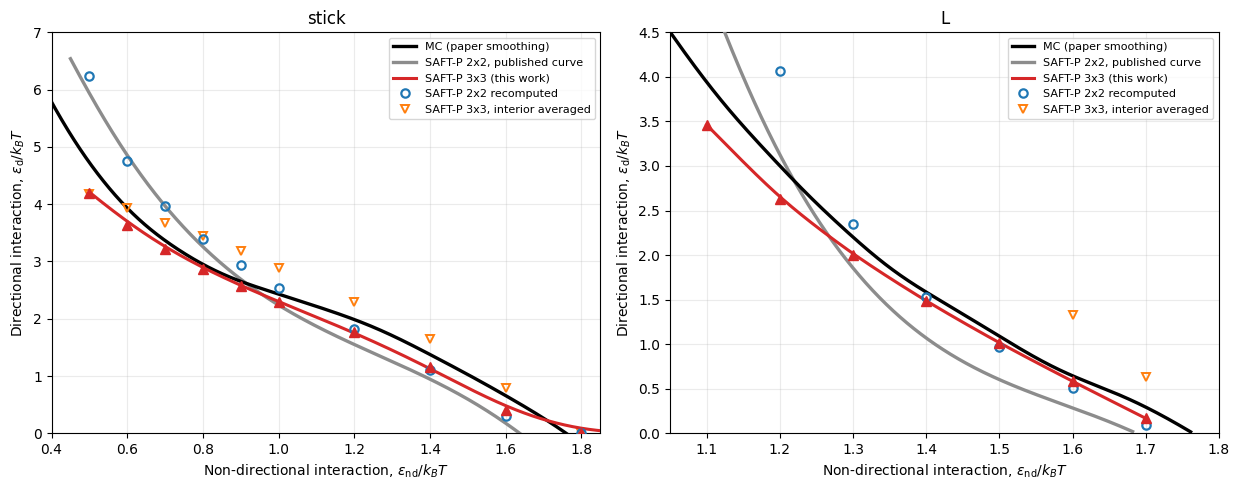

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0))
for ax, geom, tab in zip(axes, ('stick', 'L'), (stick_tab, L_tab)):
    xm, ym = tab['mc_curve']
    xs, ys = tab['pub_curve']

    ax.plot(xm, ym, 'k-',  lw=2.4, zorder=6, label='MC (paper smoothing)')
    ax.plot(xs, ys, '-',   color='0.55', lw=2.4, zorder=5,
            label='SAFT-P 2x2, published curve')

    ec = tab['ec']
    xg, yg = apply_paper_smoothing(geom, ec, tab['a3o'])
    ax.plot(xg, yg, '-', color='tab:red', lw=2.2, zorder=7, label='SAFT-P 3x3 (this work)')
    ax.plot(ec, tab['a3o'], '^', color='tab:red', ms=7, zorder=8)
    ax.plot(ec, tab['a2'],  'o', color='tab:blue', ms=6, mfc='none', mew=1.6, zorder=7,
            label='SAFT-P 2x2 recomputed')
    ax.plot(ec, tab['a3n'], 'v', color='tab:orange', ms=6, mfc='none', mew=1.4, zorder=6,
            label='SAFT-P 3x3, interior averaged')

    ax.set_xlabel(r'Non-directional interaction, $\epsilon_{\rm nd}/k_BT$')
    ax.set_ylabel(r'Directional interaction, $\varepsilon_{\rm d}/k_BT$')
    ax.set_title(geom)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, loc='upper right')
axes[0].set_xlim(0.4, 1.85); axes[0].set_ylim(0, 7)
axes[1].set_xlim(1.05, 1.8); axes[1].set_ylim(0, 4.5)
fig.tight_layout()
fig.savefig(os.path.join(DATA, '..', 'fig_critical_line_2x2_3x3_MC.png'), dpi=200)
plt.show()

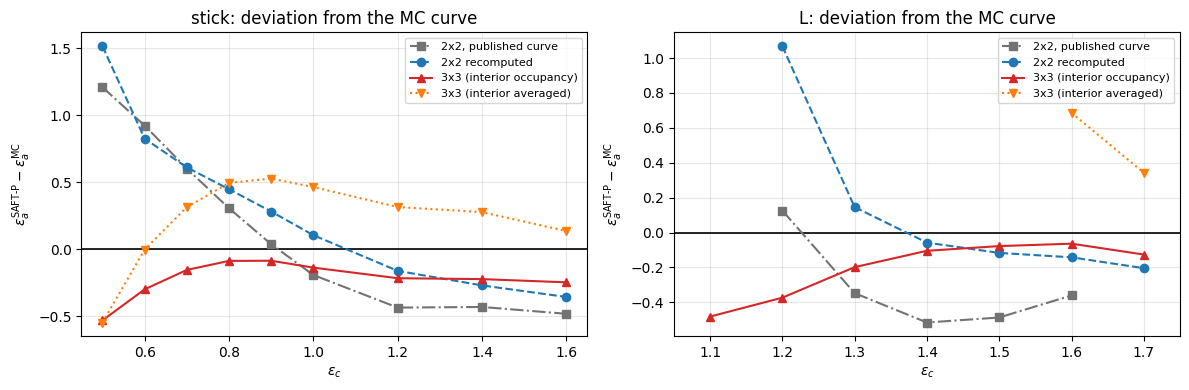

In [6]:
# deviation from the paper's MC curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4.0))
for ax, geom, tab in zip(axes, ('stick', 'L'), (stick_tab, L_tab)):
    ec, mc = tab['ec'], tab['mc']
    ax.axhline(0, color='k', lw=1.2)
    ax.plot(ec, tab['pub'] - mc, 's-.', color='0.45',      label='2x2, published curve')
    ax.plot(ec, tab['a2']  - mc, 'o--', color='tab:blue',   label='2x2 recomputed')
    ax.plot(ec, tab['a3o'] - mc, '^-',  color='tab:red',    label='3x3 (interior occupancy)')
    ax.plot(ec, tab['a3n'] - mc, 'v:',  color='tab:orange', label='3x3 (interior averaged)')
    ax.set_xlabel(r'$\epsilon_c$')
    ax.set_ylabel(r'$\varepsilon_a^{\rm SAFT\text{-}P} - \varepsilon_a^{\rm MC}$')
    ax.set_title(f'{geom}: deviation from the MC curve')
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
    ax.set_xlim(*( (0.45, 1.65) if geom == 'stick' else (1.05, 1.75) ))
fig.tight_layout()
fig.savefig(os.path.join(DATA, '..', 'fig_critical_line_deviation_from_MC.png'), dpi=200)
plt.show()

## 3. Which 2x2 file the figure is built from

The figure notebook reads `spinodal_{stick,l}_shaped_reduced_scan.npz`, but
`spinodal_{stick,l}_shaped.ipynb` — the notebook in the repo that generates the 2x2 scan —
writes `spinodal_{simple,l}_reduced_square_use4patch.npz`.  For the stick the two nearly
agree; for the L they do not.  Re-running the 2x2 calculation here reproduces `_use4patch`,
which is why the "2x2 recomputed" row sits above the "paper 2x2" row in the L table.

This does not change the 2x2-vs-3x3 conclusion (3x3 improves on *either* 2x2 line), but it is
worth resolving before resubmission: the published L curve is the more favourable of the two.

In [7]:
for a, b in [('spinodal_stick_shaped_reduced_scan', 'spinodal_simple_reduced_square_use4patch'),
             ('spinodal_l_shaped_reduced_scan',    'spinodal_l_reduced_square_use4patch')]:
    out = []
    for f in (a, b):
        p = os.path.join(DATA, f + '.npz')
        if not os.path.exists(p):
            out.append(None); continue
        pts = np.load(p)['points']
        u = np.unique(np.round(pts[:, 1], 6))
        lo = np.array([pts[np.abs(pts[:, 1] - c) < 1e-9, 0].min() for c in u])
        out.append((u, lo))
    if None in out:
        continue
    print(f"{a}   vs   {b}")
    grid = np.linspace(max(out[0][0].min(), out[1][0].min()),
                       min(out[0][0].max(), out[1][0].max()), 9)
    for g in grid:
        v0 = np.interp(g, out[0][0], out[0][1])
        v1 = np.interp(g, out[1][0], out[1][1])
        print(f"   eps_c={g:6.3f}   eps_a = {v0:6.3f}  vs  {v1:6.3f}   (diff {v1-v0:+.3f})")
    print()

spinodal_stick_shaped_reduced_scan   vs   spinodal_simple_reduced_square_use4patch
   eps_c= 0.500   eps_a =  5.800  vs   6.400   (diff +0.600)
   eps_c= 0.700   eps_a =  4.000  vs   4.000   (diff +0.000)
   eps_c= 0.900   eps_a =  2.743  vs   3.143   (diff +0.400)
   eps_c= 1.100   eps_a =  2.057  vs   2.286   (diff +0.229)
   eps_c= 1.300   eps_a =  1.229  vs   1.629   (diff +0.400)
   eps_c= 1.500   eps_a =  0.371  vs   0.771   (diff +0.400)
   eps_c= 1.700   eps_a =  0.000  vs   0.000   (diff +0.000)
   eps_c= 1.900   eps_a =  0.000  vs   0.000   (diff +0.000)
   eps_c= 2.100   eps_a =  0.000  vs   0.000   (diff +0.000)

spinodal_l_shaped_reduced_scan   vs   spinodal_l_reduced_square_use4patch
   eps_c= 1.134   eps_a =  4.364  vs   7.100   (diff +2.736)
   eps_c= 1.242   eps_a =  2.364  vs   3.450   (diff +1.086)
   eps_c= 1.349   eps_a =  1.460  vs   1.950   (diff +0.490)
   eps_c= 1.457   eps_a =  0.877  vs   1.263   (diff +0.385)
   eps_c= 1.565   eps_a =  0.347  vs   0.750   (d

## 4. What to write for R2C1

Fill in from section 2:

> To test the sensitivity of our predictions to the cluster size we repeated the calculation
> with a $3\times3$ plaquette (9 sites, 12 internal bonds, three-slot boundary super-edges, 27
> super-edge types).  Holding the class definition fixed, the critical line moves by
> $\Delta\varepsilon_a \sim \dots$ and the RMS deviation from the simulation line changes from
> $\dots$ ($2\times2$) to $\dots$ ($3\times3$).  The topology of the phase diagram and the
> trend with $\varepsilon_c$ are unchanged, and the larger cluster does not move the
> prediction away from simulation.

Points worth making explicitly, all of which the numbers support:

* the deviation from MC is not uniform in sign — the $2\times2$ theory overestimates
  $\varepsilon_a^{\rm crit}$ in the strongly directional regime (small $\varepsilon_c$) and
  underestimates it in the weakly directional regime, so a single "the theory overbinds"
  statement would be wrong;
* the $3\times3$ result is only meaningful once the boundary-invisible interior site is
  labelled by its occupancy — otherwise the coarse-grained model has no pure-solvent phase
  ($\phi \ge 2/27$) and the dilute branch of the binodal is unreachable.  This is a feature of
  $n \ge 3$ that does not exist at $n = 2$, and it is a reason the minimal plaquette is a
  clean construction rather than an arbitrary truncation;
* the same holds for the internal entropy inside a class (see
  `spinodal_3x3_cluster_size_check.ipynb`, section 3): with $\langle E\rangle_p$ the
  non-interacting limit is wrong by $O(0.3)$ in $f$ at $2\times2$ and worse at $3\times3$.
  This notebook keeps $\langle E\rangle_p$ deliberately, to isolate the cluster size, but the
  $g_p = -\log Z_p$ variant is the thermodynamically consistent one if a referee asks.